Задание №4. Классификация ЭЭГ (приступ / нет приступа) с помощью свёрточной нейронной сети и вейвлет-скалограмм.

Подготовка окружения и настройка параметров

In [2]:
import os, numpy as np, matplotlib.pyplot as plt
import mne, pywt, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import warnings
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

# Настройки
DATA_DIR = os.path.expanduser("~/Desktop/lab4")
IMAGE_DIR = "eeg_images"
MODEL_PATH = "eeg_cnn.pth"
FS, SEGMENT_DUR = 256, 10
N_SAMPLES = FS * SEGMENT_DUR
TARGET = 50
CH = 'FP1-F7'
WAV = 'cmor1.5-1.0'
SCALES = np.arange(10, 128)
IMG_SIZE = (224, 224)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Информация о приступах (chb08)
SZ_INFO = {
    "chb08_02.edf": [(2670, 2841)],
    "chb08_05.edf": [(2856, 3046)],
    "chb08_11.edf": [(2988, 3122)],
    "chb08_13.edf": [(2417, 2577)],
    "chb08_21.edf": [(2083, 2347)]
}
NO_SZ = ["chb08_03.edf", "chb08_04.edf", "chb08_10.edf"]

print(f"Настройки выполнены. Папка с данными: {DATA_DIR}")
print(f"Целевой канал: {CH}; устройство: {DEVICE}")

Настройки выполнены. Папка с данными: C:\Users\gsdasddj/Desktop/lab4
Целевой канал: FP1-F7; устройство: cpu


Проверка наличия файлов и чтение одного EDF

In [3]:
# Проверка файлов
print("Файлы в папке:")
for f in os.listdir(DATA_DIR):
    if f.endswith('.edf'):
        print(' -', f)

# Пробное чтение одного файла с приступом
test_f = os.path.join(DATA_DIR, 'chb08_02.edf')
if os.path.exists(test_f):
    raw = mne.io.read_raw_edf(test_f, preload=False, verbose=False)
    print(f"\nТестовый файл: chb08_02.edf")
    print(f"Каналы: {raw.ch_names}")
    print(f"Длительность: {raw.times[-1]:.0f} сек")
else:
    print("Файл chb08_02.edf не найден!")

Файлы в папке:
 - chb08_02.edf
 - chb08_03.edf
 - chb08_04.edf
 - chb08_05.edf
 - chb08_11.edf
 - chb08_13.edf
 - chb08_21.edf

Тестовый файл: chb08_02.edf
Каналы: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Длительность: 3600 сек


Функция извлечения отрезков ЭЭГ

In [4]:
def extract_segments(edf_path, ch, intervals, n, avoid=None):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    idx = raw.ch_names.index(ch)
    data = raw[idx, :][0].flatten()
    total = len(data)
    segs = []
    if intervals:   # приступные
        valid_iv = []
        for s,e in intervals:
            ss, es = int(s*FS), int(e*FS)
            if es-ss >= N_SAMPLES:
                valid_iv.append((ss, es))
        if not valid_iv:
            raise ValueError("Нет подходящих интервалов")
        per = int(np.ceil(n / len(valid_iv)))
        for ss, es in valid_iv:
            for _ in range(per):
                if len(segs) >= n: break
                start = np.random.randint(ss, es - N_SAMPLES + 1)
                segs.append(data[start:start+N_SAMPLES])
    else:            # нормальные
        mask = np.ones(total, dtype=bool)
        if avoid:
            for s,e in avoid:
                ss, es = int(s*FS), int(e*FS)
                mask[ss:es] = False
        safe = np.where(mask)[0]
        safe = safe[safe <= total - N_SAMPLES]
        starts = np.random.choice(safe, n, replace=False)
        for st in starts:
            segs.append(data[st:st+N_SAMPLES])
    return np.array(segs)

print("Функция extract_segments() готова.")

Функция extract_segments() готова.


Функция построения скалограммы

In [5]:
def scalogram(signal, fs, scales, wave, title, fname):
    c, freqs = pywt.cwt(signal, scales, wave, sampling_period=1/fs)
    power = np.abs(c)**2
    fig = plt.figure(figsize=(IMG_SIZE[0]/100, IMG_SIZE[1]/100), dpi=100)
    plt.imshow(power, extent=[0, len(signal)/fs, freqs[-1], freqs[0]],
               aspect='auto', cmap='jet', interpolation='bilinear')
    plt.title(title, fontsize=10)
    plt.xlabel('Время, с'); plt.ylabel('Частота, Гц')
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

print("Функция scalogram() готова.")

Функция scalogram() готова.


Генерация изображений для класса "приступ" (seizure)

In [6]:
sz_dir = os.path.join(IMAGE_DIR, "seizure")
os.makedirs(sz_dir, exist_ok=True)

print("Обработка приступных файлов...")
sz_segs = []
file_list = list(SZ_INFO.keys())
for i, fname in enumerate(file_list):
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"  {fname} – файл отсутствует")
        continue
    need = max(1, TARGET // len(file_list))
    if i == len(file_list)-1:
        need = TARGET - len(sz_segs)
    segs = extract_segments(path, CH, SZ_INFO[fname], need)
    sz_segs.extend(segs)
    print(f"  {fname}: извлечено {len(segs)} отрезков (всего {len(sz_segs)})")

while len(sz_segs) < TARGET:
    segs = extract_segments(os.path.join(DATA_DIR, file_list[0]), CH, SZ_INFO[file_list[0]], 1)
    sz_segs.append(segs[0])

# Сохранение изображений
for idx, seg in enumerate(sz_segs[:TARGET]):
    fname = os.path.join(sz_dir, f"seizure_{idx:03d}.png")
    scalogram(seg, FS, SCALES, WAV, "Скалограмма (приступ)", fname)
    if (idx+1) % 10 == 0 or idx == 0:
        print(f"  Сохранено {idx+1} изображений приступов")

print(f"\nГотово: {len(os.listdir(sz_dir))} файлов в папке 'seizure'")

Обработка приступных файлов...
  chb08_02.edf: извлечено 10 отрезков (всего 10)
  chb08_05.edf: извлечено 10 отрезков (всего 20)
  chb08_11.edf: извлечено 10 отрезков (всего 30)
  chb08_13.edf: извлечено 10 отрезков (всего 40)
  chb08_21.edf: извлечено 10 отрезков (всего 50)
  Сохранено 1 изображений приступов
  Сохранено 10 изображений приступов
  Сохранено 20 изображений приступов
  Сохранено 30 изображений приступов
  Сохранено 40 изображений приступов
  Сохранено 50 изображений приступов

Готово: 50 файлов в папке 'seizure'


Генерация изображений для класса "норма" (no_seizure)

In [7]:
no_sz_dir = os.path.join(IMAGE_DIR, "no_seizure")
os.makedirs(no_sz_dir, exist_ok=True)

print("Обработка нормальных файлов...")
no_segs = []
# собираем все приступные интервалы для исключения
all_sz = [iv for lst in SZ_INFO.values() for iv in lst]

for i, fname in enumerate(NO_SZ):
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"  {fname} – файл отсутствует")
        continue
    need = max(1, TARGET // len(NO_SZ))
    if i == len(NO_SZ)-1:
        need = TARGET - len(no_segs)
    segs = extract_segments(path, CH, None, need, avoid=all_sz)
    no_segs.extend(segs)
    print(f"  {fname}: извлечено {len(segs)} отрезков (всего {len(no_segs)})")

while len(no_segs) < TARGET:
    segs = extract_segments(os.path.join(DATA_DIR, NO_SZ[0]), CH, None, 1, avoid=all_sz)
    no_segs.append(segs[0])

for idx, seg in enumerate(no_segs[:TARGET]):
    fname = os.path.join(no_sz_dir, f"no_seizure_{idx:03d}.png")
    scalogram(seg, FS, SCALES, WAV, "Скалограмма (норма)", fname)
    if (idx+1) % 10 == 0 or idx == 0:
        print(f"  Сохранено {idx+1} изображений нормы")

print(f"\nГотово: {len(os.listdir(no_sz_dir))} файлов в папке 'no_seizure'")

Обработка нормальных файлов...
  chb08_03.edf: извлечено 16 отрезков (всего 16)
  chb08_04.edf: извлечено 16 отрезков (всего 32)
  chb08_10.edf – файл отсутствует
  Сохранено 1 изображений нормы
  Сохранено 10 изображений нормы
  Сохранено 20 изображений нормы
  Сохранено 30 изображений нормы
  Сохранено 40 изображений нормы
  Сохранено 50 изображений нормы

Готово: 50 файлов в папке 'no_seizure'


Примеры полученных скалограмм (по 2 из каждого класса)

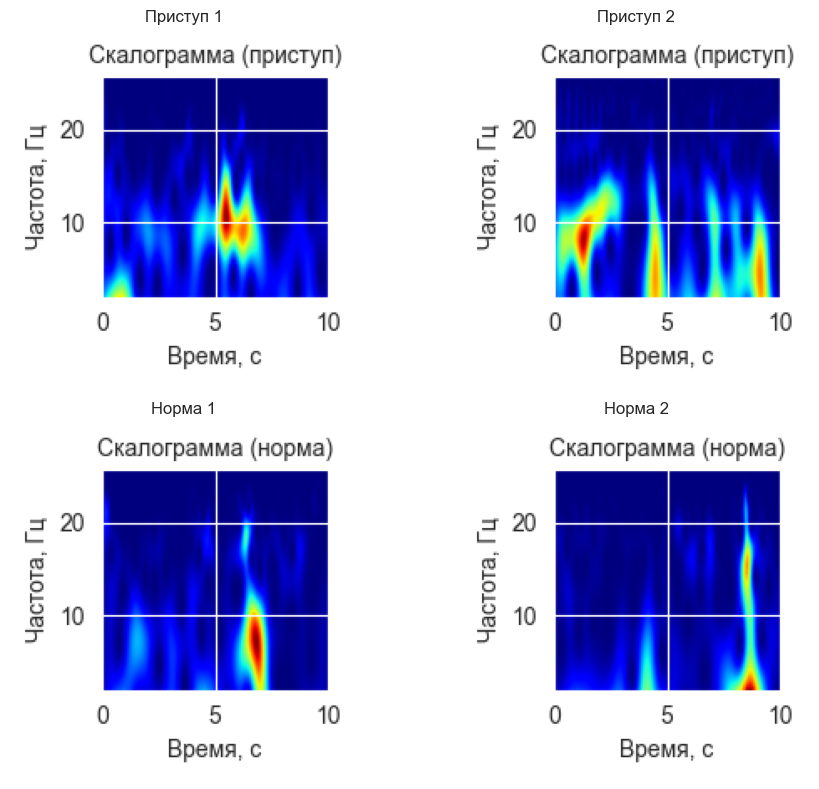

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Приступы
for i in range(2):
    img = plt.imread(os.path.join(sz_dir, f"seizure_{i:03d}.png"))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Приступ {i+1}")
    axes[0, i].axis('off')
# Норма
for i in range(2):
    img = plt.imread(os.path.join(no_sz_dir, f"no_seizure_{i:03d}.png"))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Норма {i+1}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Загрузка датасета и разделение на train/test

In [9]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(root=IMAGE_DIR, transform=transform)
print(f"Классы: {dataset.classes}, всего изображений: {len(dataset)}")

# Разделение 80/20
test_sz = int(0.2 * len(dataset))
train_sz = len(dataset) - test_sz
train_ds, test_ds = random_split(dataset, [train_sz, test_sz],
                                 generator=torch.Generator().manual_seed(42))
print(f"Обучающих: {train_sz}, тестовых: {test_sz}")

Классы: ['no_seizure', 'seizure'], всего изображений: 100
Обучающих: 80, тестовых: 20


Архитектура свёрточной сети

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.fc = nn.Sequential(
            nn.Flatten(), nn.Linear(64*28*28,128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128,2))

    def forward(self, x):
        return self.fc(self.conv(x))

model = CNN().to(DEVICE)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Параметров: 6,446,210


Обучение модели

In [19]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Начало обучения...")
train_loss_hist, train_acc_hist = [], []
for epoch in range(30):
    model.train()
    run_loss, corr, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()*imgs.size(0)
        _, pred = torch.max(out, 1)
        total += lbls.size(0)
        corr += (pred == lbls).sum().item()
    ep_loss = run_loss/total
    ep_acc = 100*corr/total
    train_loss_hist.append(ep_loss)
    train_acc_hist.append(ep_acc)
    print(f"Эпоха {epoch+1:2d} | loss {ep_loss:.4f} | acc {ep_acc:.2f}%")
print("Обучение завершено.")

Начало обучения...
Эпоха  1 | loss 0.3785 | acc 83.75%
Эпоха  2 | loss 0.4610 | acc 80.00%
Эпоха  3 | loss 0.3669 | acc 90.00%
Эпоха  4 | loss 0.3351 | acc 87.50%
Эпоха  5 | loss 0.3239 | acc 88.75%
Эпоха  6 | loss 0.3618 | acc 88.75%
Эпоха  7 | loss 0.3229 | acc 85.00%
Эпоха  8 | loss 0.2654 | acc 90.00%
Эпоха  9 | loss 0.2816 | acc 91.25%
Эпоха 10 | loss 0.3669 | acc 86.25%
Эпоха 11 | loss 0.2930 | acc 91.25%
Эпоха 12 | loss 0.2996 | acc 87.50%
Эпоха 13 | loss 0.2755 | acc 87.50%
Эпоха 14 | loss 0.2525 | acc 91.25%
Эпоха 15 | loss 0.2456 | acc 91.25%
Эпоха 16 | loss 0.2233 | acc 92.50%
Эпоха 17 | loss 0.2081 | acc 91.25%
Эпоха 18 | loss 0.1550 | acc 92.50%
Эпоха 19 | loss 0.1872 | acc 92.50%
Эпоха 20 | loss 0.1648 | acc 93.75%
Эпоха 21 | loss 0.2012 | acc 90.00%
Эпоха 22 | loss 0.1380 | acc 96.25%
Эпоха 23 | loss 0.1481 | acc 92.50%
Эпоха 24 | loss 0.1265 | acc 95.00%
Эпоха 25 | loss 0.0974 | acc 95.00%
Эпоха 26 | loss 0.1127 | acc 97.50%
Эпоха 27 | loss 0.1625 | acc 91.25%
Эпоха 28 

Графики обучения

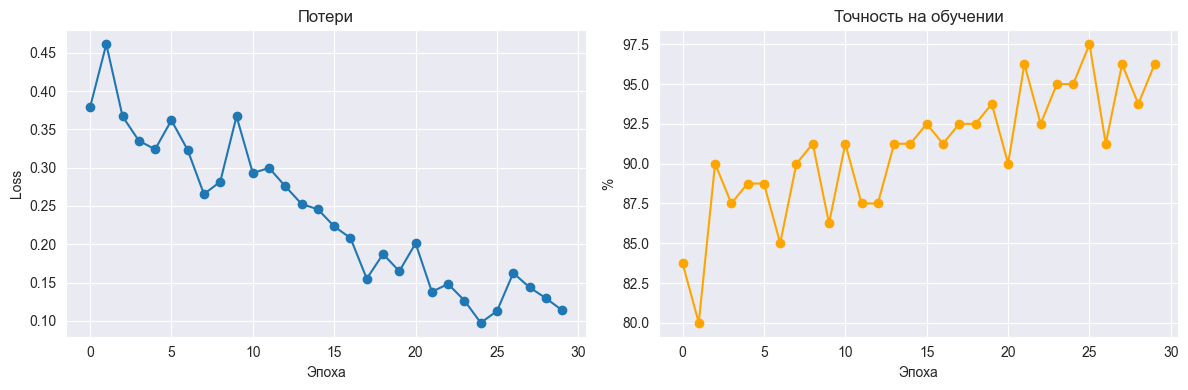

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_loss_hist, 'o-')
plt.title("Потери"); plt.xlabel("Эпоха"); plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(train_acc_hist, 'o-', color='orange')
plt.title("Точность на обучении"); plt.xlabel("Эпоха"); plt.ylabel("%")
plt.tight_layout()
plt.savefig("training_plot.png")
plt.show()

Оценка на тестовой выборке

In [14]:
model.eval()
corr, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = model(imgs)
        _, pred = torch.max(out, 1)
        total += lbls.size(0)
        corr += (pred == lbls).sum().item()
test_acc = 100*corr/total
print(f"Точность на тесте: {test_acc:.2f}%")

Точность на тесте: 70.00%


Визуализация предсказаний (первые 4 тестовых изображения)

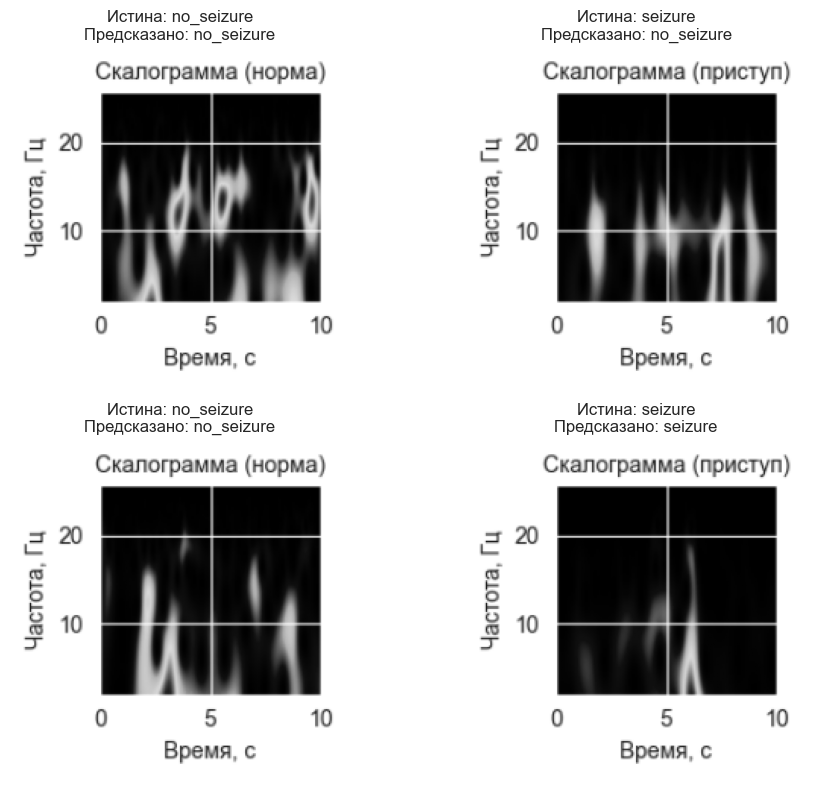

In [21]:
classes = ['no_seizure', 'seizure']
dataiter = iter(test_loader)
imgs, lbls = next(dataiter)
imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
with torch.no_grad():
    preds = torch.max(model(imgs), 1)[1]

fig, axes = plt.subplots(2,2, figsize=(10,8))
for i, ax in enumerate(axes.flat):
    img = imgs[i].cpu().squeeze().numpy()
    ax.imshow(img, cmap='gray')
    true = classes[lbls[i].item()]
    pred = classes[preds[i].item()]
    ax.set_title(f"Истина: {true}\nПредсказано: {pred}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("test_samples.png")
plt.show()

Сохранение модели

In [41]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Модель сохранена: {MODEL_PATH}")
# Проверка загрузки
model2 = CNN().to(DEVICE)
model2.load_state_dict(torch.load(MODEL_PATH))
model2.eval()
print("Загрузка модели для проверки – успешно.")

Модель сохранена: eeg_cnn.pth
Загрузка модели для проверки – успешно.


Конец эксперимента. Итоговые результаты:
- Датасет: 100 скалограмм (50 приступ / 50 норма)
- Точность на тесте (см. выше)
- Обученная модель сохранена в eeg_cnn.pth